# Homework 3 Part 2

The author acknowledges the use of Claude in the preparation or completion of this assignment. Claude was used in the following way(s) in this assignment: assisting with creating architecture plan, front end code, backend skeleton code, and general debugging.

2. [25 points] Build a post game win probability model for the NFL using data from the last five seasons.  Be sure to provide out of sample test results and calibration plots.  Compare multiple models and describe how they compare.  Clearly state which model is best and why.

In [37]:
import nfl_data_py as nfl
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [38]:
pbp = nfl.import_pbp_data([2021, 2022, 2023, 2024, 2025])

2021 done.
2022 done.
2023 done.
2024 done.
2025 done.
Downcasting floats.


In [39]:
np.random.seed(519)

In [40]:
# filter to reg season, non-null posteam
plays = pbp[
    (pbp['season_type'] == 'REG') &
    (pbp['posteam'].notna())
].copy()


In [41]:
# aggregate to game-level stats per team
team_stats = plays.groupby(['game_id', 'posteam', 'season']).agg(
    passing_yards=('passing_yards', 'sum'),
    rushing_yards=('rushing_yards', 'sum'),
    penalty_yards=('penalty_yards', 'sum'),
    first_downs=('first_down', 'sum'),
    third_down_converted=('third_down_converted', 'sum'),
    third_down_failed=('third_down_failed', 'sum'),
    fumbles_lost=('fumble_lost', 'sum'),
    interceptions=('interception', 'sum'),
).reset_index()

team_stats['turnovers'] = team_stats['fumbles_lost'] + team_stats['interceptions']
team_stats['third_down_att'] = team_stats['third_down_converted'] + team_stats['third_down_failed']
team_stats['third_down_pct'] = np.where(
    team_stats['third_down_att'] > 0,
    team_stats['third_down_converted'] / team_stats['third_down_att'],
    0.0
)

print(f"Team-game rows: {len(team_stats)}")
team_stats.head()


Team-game rows: 2718


,game_id,posteam,season,passing_yards,rushing_yards,penalty_yards,first_downs,third_down_converted,third_down_failed,fumbles_lost,interceptions,turnovers,third_down_att,third_down_pct
0,2021_01_ARI_TEN,ARI,2021,289.0,136.0,86.0,22.0,7.0,6.0,0.0,1.0,1.0,13.0,0.538462
1,2021_01_ARI_TEN,TEN,2021,218.0,86.0,30.0,17.0,5.0,9.0,2.0,1.0,3.0,14.0,0.357143
2,2021_01_BAL_LV,BAL,2021,235.0,189.0,20.0,20.0,3.0,9.0,2.0,0.0,2.0,12.0,0.250000
3,2021_01_BAL_LV,LV,2021,435.0,82.0,113.0,26.0,7.0,8.0,0.0,1.0,1.0,15.0,0.466667
4,2021_01_CHI_LA,CHI,2021,216.0,134.0,20.0,23.0,5.0,6.0,1.0,1.0,2.0,11.0,0.454545


In [42]:
# self-merge: join each team's row with the other team's row in the same game
game_df = team_stats.merge(
    team_stats,
    on=['game_id', 'season'],
    suffixes=('', '_opp')
)

# keep only rows where the two teams are different (team vs opponent, not team vs itself)
game_df = game_df[game_df['posteam'] != game_df['posteam_opp']].reset_index(drop=True)

# rename opponent columns for clarity
game_df = game_df.rename(columns={
    'passing_yards_opp': 'passing_yards_allowed',
    'rushing_yards_opp': 'rushing_yards_allowed',
    'penalty_yards_opp': 'penalty_yards_opp',
    'first_downs_opp': 'first_downs_allowed',
    'third_down_pct_opp': 'third_down_pct_opp',
    'turnovers_opp': 'turnovers_forced',
})

print(f"Merged game-team rows: {len(game_df)}")


Merged game-team rows: 2718


In [43]:
schedule = nfl.import_schedules([2021, 2022, 2023, 2024, 2025])
schedule = schedule[schedule['game_type'] == 'REG'][['game_id', 'home_team', 'away_team', 'home_score', 'away_score']].copy()

game_df = game_df.merge(schedule, on='game_id', how='inner')

game_df['is_home'] = (game_df['posteam'] == game_df['home_team']).astype(int)
game_df['points'] = np.where(game_df['is_home'] == 1, game_df['home_score'], game_df['away_score'])
game_df['points_allowed'] = np.where(game_df['is_home'] == 1, game_df['away_score'], game_df['home_score'])

game_df = game_df[game_df['points'] != game_df['points_allowed']].copy()
game_df['win'] = (game_df['points'] > game_df['points_allowed']).astype(int)

In [44]:
# keep one row per game to avoid double-counting (same as CFB notebook: df.iloc[1::2])
model_ready = game_df.iloc[1::2].reset_index(drop=True)
print(f"Games after filtering: {len(model_ready)}")
model_ready.head()


Games after filtering: 1355


,game_id,posteam,season,passing_yards,rushing_yards,penalty_yards,first_downs,third_down_converted,third_down_failed,fumbles_lost,...,third_down_att_opp,third_down_pct_opp,home_team,away_team,home_score,away_score,is_home,points,points_allowed,win
0,2021_01_ARI_TEN,TEN,2021,218.0,86.0,30.0,17.0,5.0,9.0,2.0,...,13.0,0.538462,TEN,ARI,13.0,38.0,1,13.0,38.0,0
1,2021_01_BAL_LV,LV,2021,435.0,82.0,113.0,26.0,7.0,8.0,0.0,...,12.0,0.250000,LV,BAL,33.0,27.0,1,33.0,27.0,1
2,2021_01_CHI_LA,LA,2021,321.0,74.0,51.0,18.0,6.0,5.0,0.0,...,11.0,0.454545,LA,CHI,34.0,14.0,1,34.0,14.0,1
3,2021_01_CLE_KC,KC,2021,337.0,73.0,30.0,21.0,9.0,4.0,0.0,...,7.0,0.285714,KC,CLE,33.0,29.0,1,33.0,29.0,1
4,2021_01_DAL_TB,TB,2021,379.0,52.0,35.0,24.0,5.0,6.0,2.0,...,17.0,0.529412,TB,DAL,31.0,29.0,1,31.0,29.0,1


In [45]:
# differential features 
model_ready['turnover_margin'] = model_ready['turnovers_forced'] - model_ready['turnovers']
model_ready['pass_yards_diff'] = model_ready['passing_yards'] - model_ready['passing_yards_allowed']
model_ready['rush_yards_diff'] = model_ready['rushing_yards'] - model_ready['rushing_yards_allowed']
model_ready['first_downs_diff'] = model_ready['first_downs'] - model_ready['first_downs_allowed']
model_ready['third_down_pct_diff'] = model_ready['third_down_pct'] - model_ready['third_down_pct_opp']
model_ready['penalty_yards_diff'] = model_ready['penalty_yards'] - model_ready['penalty_yards_opp']

diff_predictors = [
    'is_home', 'turnover_margin', 'pass_yards_diff', 'rush_yards_diff',
    'first_downs_diff', 'third_down_pct_diff', 'penalty_yards_diff',
]

ind_predictors = [
    'is_home', 'turnovers', 'turnovers_forced',
    'rushing_yards', 'rushing_yards_allowed',
    'passing_yards', 'passing_yards_allowed',
    'first_downs', 'first_downs_allowed',
    'third_down_pct', 'third_down_pct_opp',
    'penalty_yards',
]

model_df = model_ready.dropna(subset=['win'] + diff_predictors + ind_predictors)
print(f"Final modeling dataset: {len(model_df)} games")
model_df[diff_predictors + ['win']].describe()


Final modeling dataset: 1355 games


,is_home,turnover_margin,pass_yards_diff,rush_yards_diff,first_downs_diff,third_down_pct_diff,penalty_yards_diff,win
count,1355.000000,1355.000000,1355.000000,1355.000000,1355.000000,1355.000000,1355.000000,1355.000000
mean,0.496679,-0.063469,-0.877491,-1.740221,-0.183026,-0.002169,0.389668,0.484871
std,0.500174,1.747871,94.418701,80.659233,7.391090,0.197734,36.294018,0.499956
min,0.000000,-6.000000,-386.000000,-275.000000,-27.000000,-0.666667,-122.000000,0.000000
25%,0.000000,-1.000000,-63.000000,-54.000000,-5.000000,-0.133333,-23.000000,0.000000
50%,0.000000,0.000000,2.000000,-2.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,63.000000,53.000000,5.000000,0.128788,23.000000,1.000000
max,1.000000,6.000000,357.000000,281.000000,22.000000,0.686869,150.000000,1.000000


## Model 1: Logistic Regression

In [46]:
# feature engineering
X_diff = model_df[diff_predictors]
X_ind = model_df[ind_predictors]
y = model_df['win']
strata = model_df['season']

X_train_diff, X_test_diff, y_train, y_test = train_test_split(
    X_diff, y, test_size=0.20, random_state=2026, stratify=strata
)

X_train_ind = X_ind.loc[X_train_diff.index]
X_test_ind = X_ind.loc[X_test_diff.index]

test_seasons = model_df.loc[X_test_diff.index, 'season']

# standardize
scaler_diff = StandardScaler()
X_train_diff_s = pd.DataFrame(scaler_diff.fit_transform(X_train_diff), columns=diff_predictors, index=X_train_diff.index)
X_test_diff_s = pd.DataFrame(scaler_diff.transform(X_test_diff), columns=diff_predictors, index=X_test_diff.index)

scaler_ind = StandardScaler()
X_train_ind_s = pd.DataFrame(scaler_ind.fit_transform(X_train_ind), columns=ind_predictors, index=X_train_ind.index)
X_test_ind_s = pd.DataFrame(scaler_ind.transform(X_test_ind), columns=ind_predictors, index=X_test_ind.index)

print(f"Train: {len(X_train_diff)}, Test: {len(X_test_diff)}")


Train: 1084, Test: 271


In [47]:
def plot_overall_calibration(y_true, y_probs, title_suffix=""):
    df_cal = pd.DataFrame({'actual': y_true.values, 'pred': y_probs})
    df_cal['prob_bin'] = pd.cut(df_cal['pred'], bins=np.linspace(0, 1, 11), include_lowest=True)

    agg = df_cal.groupby('prob_bin', observed=False).agg(
        mean_pred=('pred', 'mean'),
        actual_win_rate=('actual', 'mean'),
        game_count=('actual', 'count')
    ).reset_index().dropna()

    plt.figure(figsize=(8, 6))
    plt.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect Calibration')
    plt.plot(agg['mean_pred'], agg['actual_win_rate'], 'o-', color='royalblue', linewidth=2)
    plt.scatter(agg['mean_pred'], agg['actual_win_rate'], s=agg['game_count'] * 0.8, color='royalblue', alpha=0.7)
    plt.xlim(0, 1); plt.ylim(0, 1)
    plt.xlabel('Mean Predicted Win Probability', fontweight='bold')
    plt.ylabel('Observed Win Rate', fontweight='bold')
    plt.title(f'Overall Win Probability Calibration {title_suffix}', fontsize=13, fontweight='bold')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()


def plot_season_calibration(y_true, y_probs, seasons_series):
    df_cal = pd.DataFrame({'actual': y_true.values, 'pred': y_probs, 'season': seasons_series.values})
    df_cal['prob_bin'] = pd.cut(df_cal['pred'], bins=np.linspace(0, 1, 11), include_lowest=True)

    agg = df_cal.groupby(['season', 'prob_bin'], observed=False).agg(
        mean_pred=('pred', 'mean'),
        actual_win_rate=('actual', 'mean'),
        game_count=('actual', 'count')
    ).reset_index().dropna()

    unique_seasons = sorted(agg['season'].unique())
    n = len(unique_seasons)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), sharex=True, sharey=True)
    axes = axes.flatten()

    for idx, s in enumerate(unique_seasons):
        ax = axes[idx]
        sub = agg[agg['season'] == s]
        ax.plot([0, 1], [0, 1], 'r--', linewidth=1.2)
        ax.plot(sub['mean_pred'], sub['actual_win_rate'], 'o-', color='royalblue', linewidth=1.5)
        ax.scatter(sub['mean_pred'], sub['actual_win_rate'], s=sub['game_count'] * 1.5, color='royalblue', alpha=0.7)
        ax.set_title(f'Season {s}', fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.5)

    for idx in range(n, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Win Probability Calibration by Season (Test Set)', fontsize=14, fontweight='bold')
    fig.text(0.5, 0.02, 'Mean Predicted Win Probability', ha='center', fontweight='bold')
    fig.text(0.02, 0.5, 'Observed Win Rate', va='center', rotation='vertical', fontweight='bold')
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
    plt.show()


def eval_model(name, y_true, y_probs):
    pred_class = (y_probs >= 0.5).astype(int)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, pred_class),
        'ROC AUC': roc_auc_score(y_true, y_probs),
        'Log Loss': log_loss(y_true, y_probs),
        'Brier Score': brier_score_loss(y_true, y_probs),
    }


In [48]:
X_train_sm = sm.add_constant(X_train_diff_s)
X_test_sm = sm.add_constant(X_test_diff_s)

logit_model = sm.Logit(y_train, X_train_sm).fit(disp=False)

# feature importance table
summary_df = pd.DataFrame({
    'Predictor': logit_model.params.index,
    'Std Beta': logit_model.params.values,
    'Odds Ratio (1 SD)': np.exp(logit_model.params.values),
    'z-statistic': logit_model.tvalues.values,
    'p-value': logit_model.pvalues.values
})
summary_df = summary_df[summary_df['Predictor'] != 'const'].copy()
summary_df['Importance (|z|)'] = summary_df['z-statistic'].abs()
summary_df = summary_df.sort_values(by='Importance (|z|)', ascending=False)
print(summary_df.to_string(index=False))


          Predictor  Std Beta  Odds Ratio (1 SD)  z-statistic      p-value  Importance (|z|)
    turnover_margin  1.723738           5.605441    13.723323 7.361273e-43         13.723323
third_down_pct_diff  0.898279           2.455375     7.554992 4.188863e-14          7.554992
    rush_yards_diff  0.807452           2.242188     5.546179 2.919797e-08          5.546179
    pass_yards_diff  0.593129           1.809642     4.229485 2.342266e-05          4.229485
 penalty_yards_diff -0.254730           0.775126    -2.841921 4.484265e-03          2.841921
   first_downs_diff  0.422631           1.525972     2.454929 1.409124e-02          2.454929
            is_home  0.011258           1.011322     0.126709 8.991705e-01          0.126709


/var/folders/jr/vc14h5lx5gz41584rmkfgl380000gn/T/ipykernel_4164/1151382479.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Importance (|z|)", y="Predictor", palette="mako")


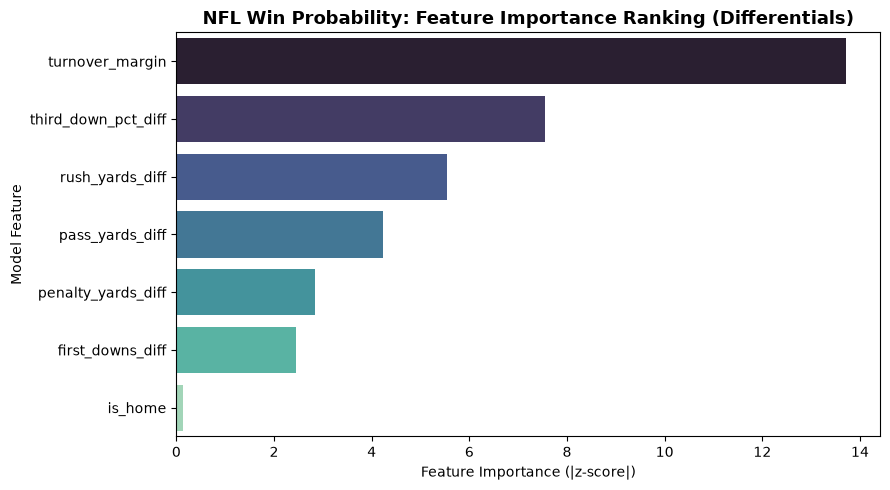

In [49]:
plt.figure(figsize=(9, 5))
sns.barplot(data=summary_df, x="Importance (|z|)", y="Predictor", palette="mako")
plt.title("NFL Win Probability: Feature Importance Ranking (Differentials)", fontsize=13, fontweight="bold")
plt.xlabel("Feature Importance (|z-score|)")
plt.ylabel("Model Feature")
plt.tight_layout()
plt.show()

In [50]:
pred_probs_diff = logit_model.predict(X_test_sm)
pred_class_diff = (pred_probs_diff >= 0.5).astype(int)

metrics_diff = pd.DataFrame({
    "Metric": ["Accuracy", "ROC AUC", "Log Loss", "Brier Score"],
    "Test Score": [
        accuracy_score(y_test, pred_class_diff),
        roc_auc_score(y_test, pred_probs_diff),
        log_loss(y_test, pred_probs_diff),
        brier_score_loss(y_test, pred_probs_diff)
    ]
})

print("Out-of-Sample Performance (Differentials Model):")
print(metrics_diff.to_string(index=False))

Out-of-Sample Performance (Differentials Model):
     Metric  Test Score
   Accuracy    0.797048
    ROC AUC    0.892086
   Log Loss    0.421321
Brier Score    0.136460


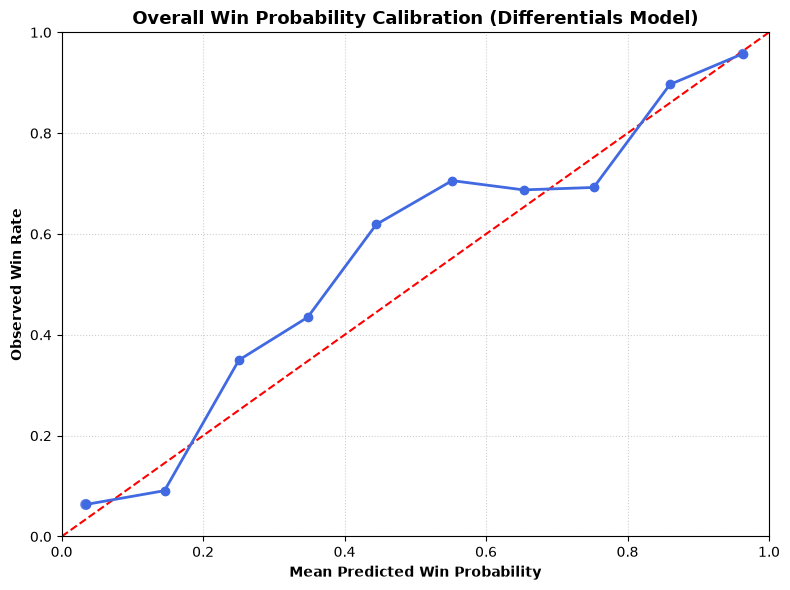

In [51]:
def plot_overall_calibration(y_true, y_probs, title_suffix=""):
    df_cal = pd.DataFrame({"actual": y_true, "pred": y_probs})
    df_cal["prob_bin"] = pd.cut(df_cal["pred"], bins=np.linspace(0, 1, 11), include_lowest=True)
    
    agg = df_cal.groupby("prob_bin", observed=False).agg(
        mean_pred=("pred", "mean"),
        actual_win_rate=("actual", "mean"),
        game_count=("actual", "count")
    ).reset_index().dropna()

    plt.figure(figsize=(8, 6))
    plt.plot([0, 1], [0, 1], "r--", linewidth=1.5, label="Perfect Calibration")
    plt.plot(agg["mean_pred"], agg["actual_win_rate"], "o-", color="royalblue", linewidth=2)
    plt.scatter(agg["mean_pred"], agg["actual_win_rate"], s=agg["game_count"] * 0.8, color="royalblue", alpha=0.7)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("Mean Predicted Win Probability", fontweight="bold")
    plt.ylabel("Observed Win Rate", fontweight="bold")
    plt.title(f"Overall Win Probability Calibration {title_suffix}", fontsize=13, fontweight="bold")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_overall_calibration(y_test, pred_probs_diff, "(Differentials Model)")

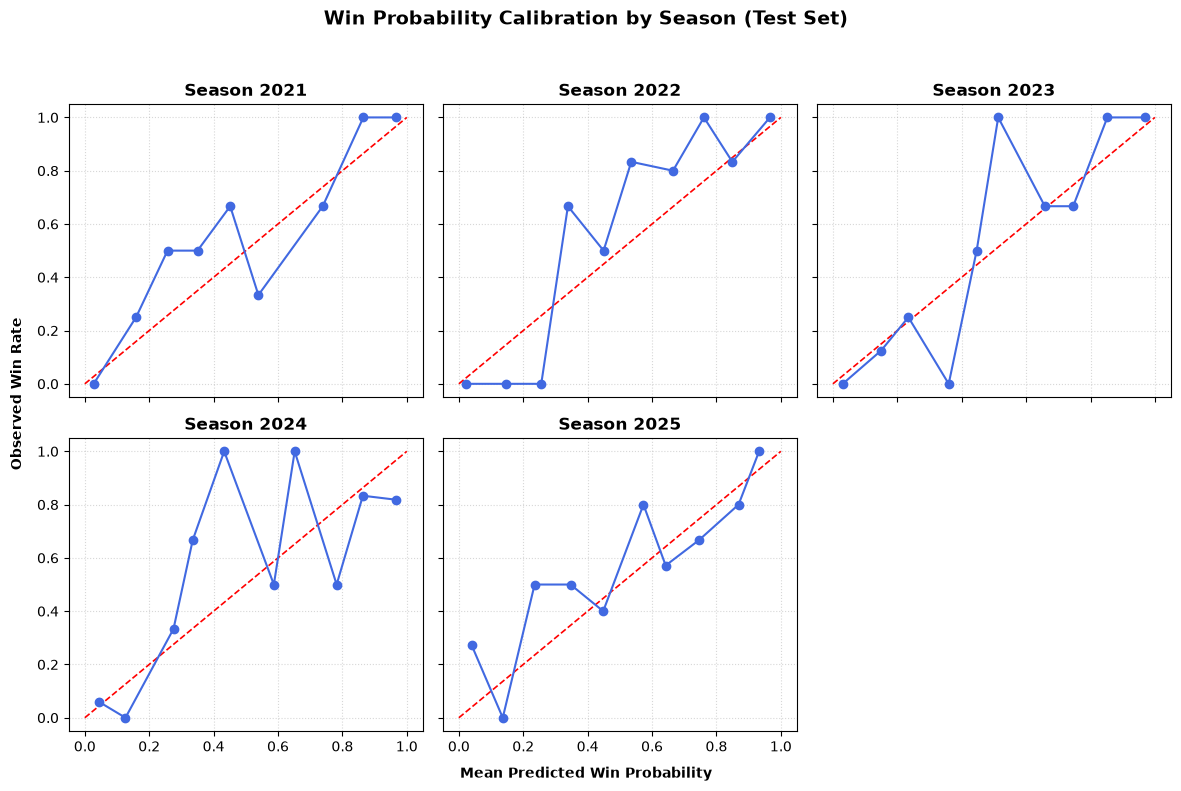

In [52]:
plot_season_calibration(y_test, pred_probs_diff, test_seasons)


## Model 2: Random Forest

In [53]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=2026)
rf_model.fit(X_train_diff_s, y_train)

rf_probs = rf_model.predict_proba(X_test_diff_s)[:, 1]
rf_metrics = eval_model('Random Forest', y_test, rf_probs)

print('Out-of-Sample Performance (Random Forest):')
print(pd.DataFrame([rf_metrics]).to_string(index=False))


Out-of-Sample Performance (Random Forest):
        Model  Accuracy  ROC AUC  Log Loss  Brier Score
Random Forest  0.785978 0.883421  0.448856     0.145674


/var/folders/jr/vc14h5lx5gz41584rmkfgl380000gn/T/ipykernel_4164/3257228819.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_imp, x='Importance', y='Predictor', palette='mako')


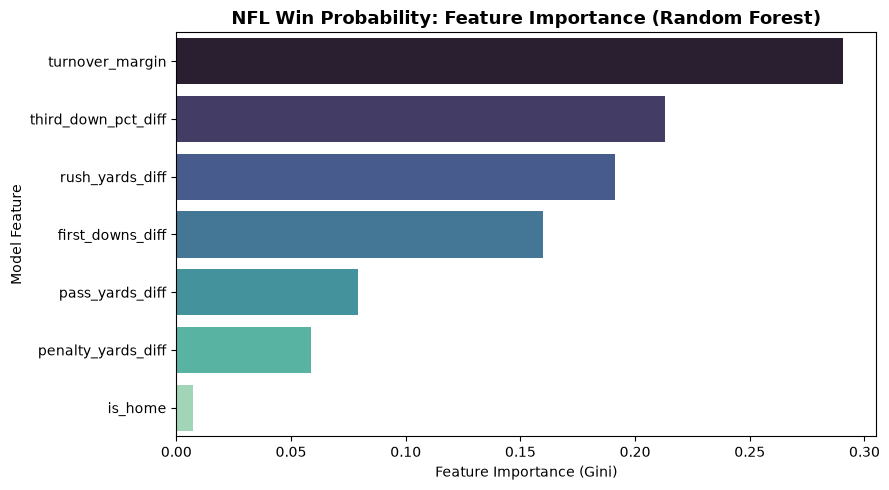

In [54]:
rf_imp = pd.DataFrame({
    'Predictor': diff_predictors,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=rf_imp, x='Importance', y='Predictor', palette='mako')
plt.title('NFL Win Probability: Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance (Gini)')
plt.ylabel('Model Feature')
plt.tight_layout()
plt.show()


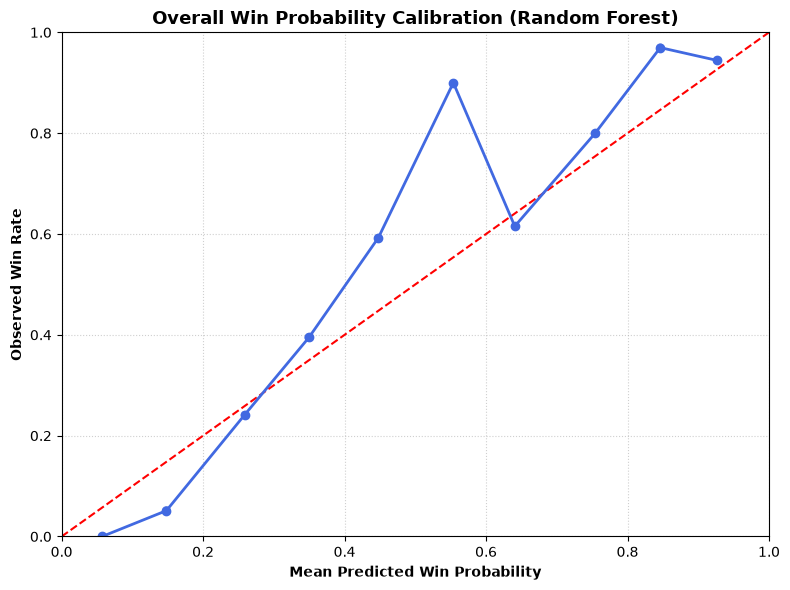

In [55]:
plot_overall_calibration(y_test, rf_probs, '(Random Forest)')


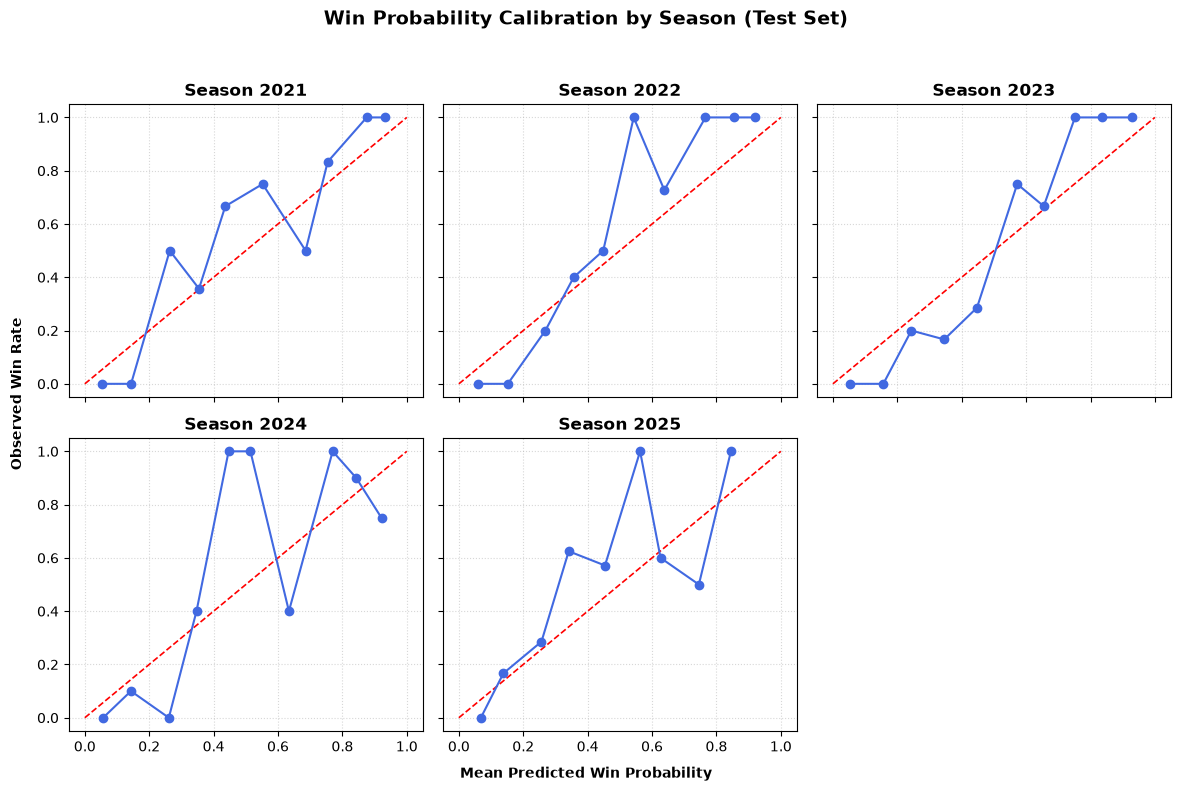

In [56]:
plot_season_calibration(y_test, rf_probs, test_seasons)


## Model 3: SVM

In [57]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', probability=True, random_state=2026)
svm_model.fit(X_train_diff_s, y_train)

svm_probs = svm_model.predict_proba(X_test_diff_s)[:, 1]
svm_metrics = eval_model('SVM', y_test, svm_probs)

print('Out-of-Sample Performance (SVM):')
print(pd.DataFrame([svm_metrics]).to_string(index=False))


Out-of-Sample Performance (SVM):
Model  Accuracy  ROC AUC  Log Loss  Brier Score
  SVM  0.789668  0.89225  0.421215     0.136699


/Users/hannahw/school/ITCS5010/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


/var/folders/jr/vc14h5lx5gz41584rmkfgl380000gn/T/ipykernel_4164/2458651084.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=svm_imp, x='Importance', y='Predictor', palette='mako')


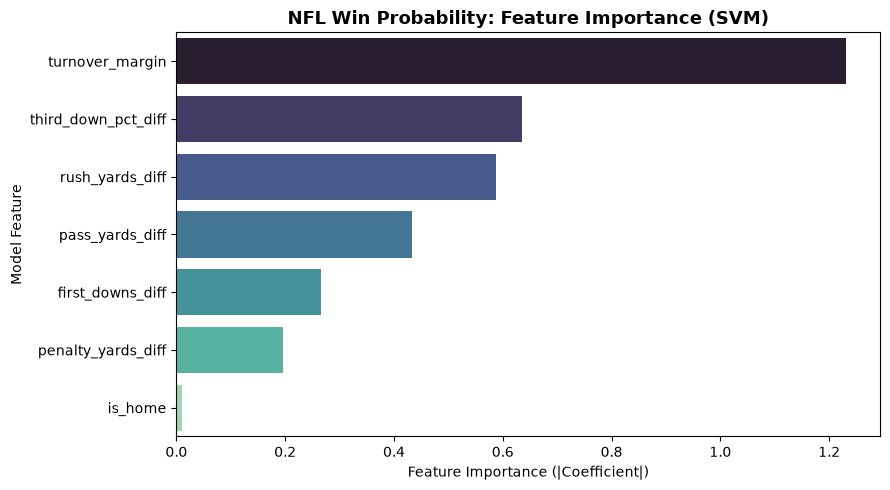

In [58]:
svm_imp = pd.DataFrame({
    'Predictor': diff_predictors,
    'Importance': np.abs(svm_model.coef_[0])
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=svm_imp, x='Importance', y='Predictor', palette='mako')
plt.title('NFL Win Probability: Feature Importance (SVM)', fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance (|Coefficient|)')
plt.ylabel('Model Feature')
plt.tight_layout()
plt.show()


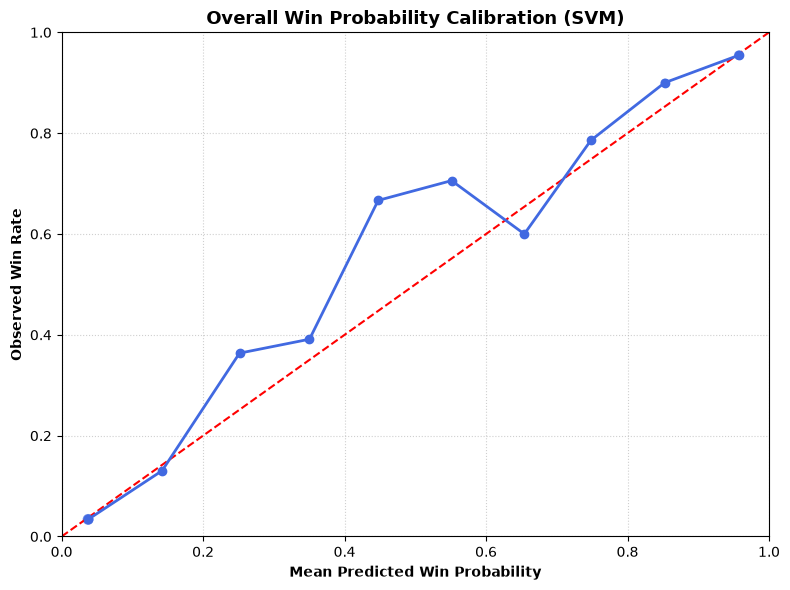

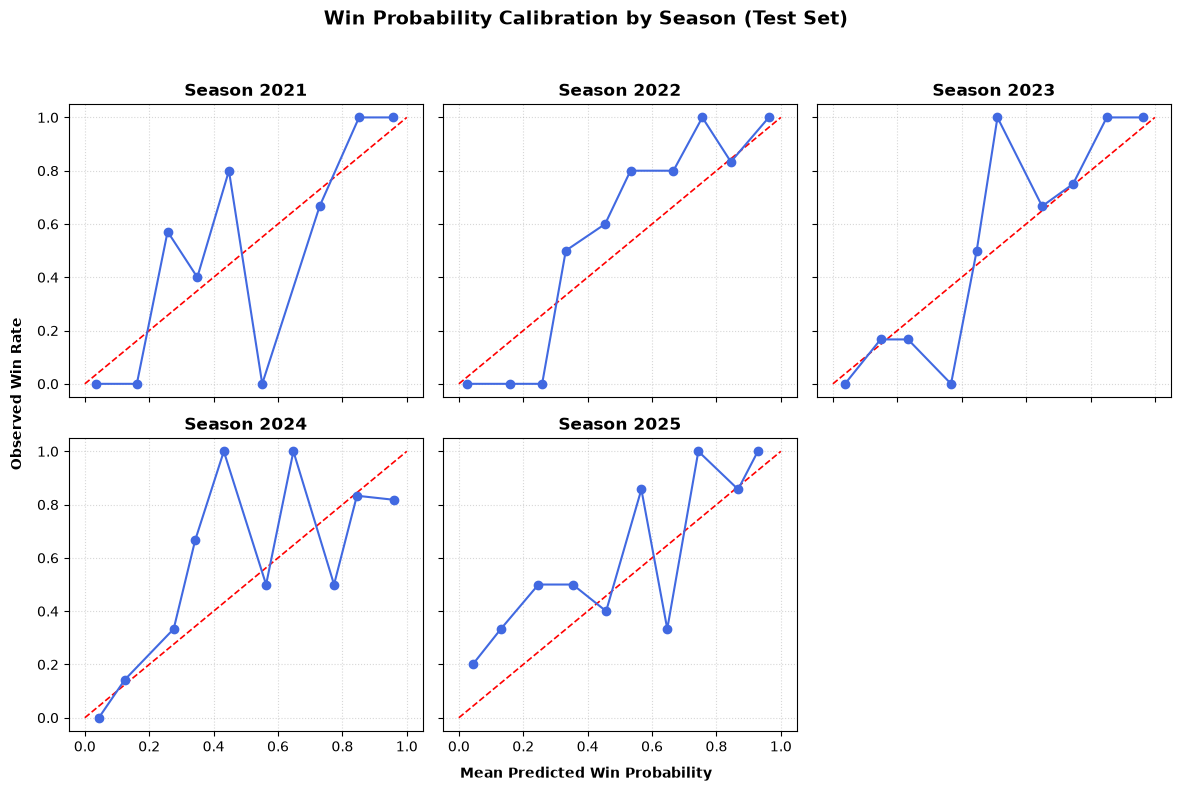

In [59]:
plot_overall_calibration(y_test, svm_probs, '(SVM)')
plot_season_calibration(y_test, svm_probs, test_seasons)


## Model Comparison

In [60]:
logit_probs = logit_model.predict(X_test_sm)
rf_probs = rf_model.predict_proba(X_test_diff_s)[:, 1]
svm_probs = svm_model.predict_proba(X_test_diff_s)[:, 1]

metrics_diff = eval_model('Logistic Regression', y_test, logit_probs)
rf_metrics = eval_model('Random Forest', y_test, rf_probs)
svm_metrics = eval_model('SVM', y_test, svm_probs)

comparison = pd.DataFrame([metrics_diff, rf_metrics, svm_metrics])
comparison = comparison.set_index('Model')
print(comparison.to_string())


                     Accuracy   ROC AUC  Log Loss  Brier Score
Model                                                         
Logistic Regression  0.797048  0.892086  0.421321     0.136460
Random Forest        0.785978  0.883421  0.448856     0.145674
SVM                  0.789668  0.892250  0.421215     0.136699


I tested three different models: logistic regression, random forest, and SVM with a linear kernel. The models performed similarly, but logistic regression performed best overall on accuracy and Brier score. SVM performed best for ROC and Log Loss. The models' calibration plots did not perfectly follow the line; however, logistic regression was better calibrated by 0.0002. Logistic regression performs better at the extremes, but SVM performs best in the middle of the chart. Logistic regression and random forest are much more overconfident in the middle area, while random forest and SVM are underconfident at the beginning. All models struggle in 2022 with being underconfident for the lower win probabilities. To enable feature importance analysis, we selected an SVM model with a linear kernel. All three models agree that turnovers, third down efficiency, and rush yard efficiency were the most important features. Rankings differed between logistic regression/SVM and random forest for first-down differences and pass-yard differences. Logistic regression ranked turnovers as the most important feature, while SVM closely followed. Despite the closeness between logistic regression and the SVM model, I think logistic regression is best. The logistic regression model is the most interpretable, as you can see the coefficients and see exactly how each feature affects win probability.